加载数据

In [1]:
import scipy.io as sio

In [2]:
wrapped_mat_path = r"data/wrapped/wrapped.mat"
gt_mat_path = r"data/gt/gt.mat"

In [3]:
wrapped_mat = sio.loadmat(wrapped_mat_path)['input']
gt_mat = sio.loadmat(gt_mat_path)['gt']

展示Wrapped与GT_Unwrapped

In [29]:
import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np
from matplotlib.ticker import MultipleLocator, FuncFormatter
def pi_formatter(x, pos):
    k = x / np.pi

    # 0
    if np.isclose(k, 0):
        return "0"

    # 接近整数倍 π
    if np.isclose(k, round(k)):
        k_int = int(round(k))
        if k_int == 1:
            return r"$\pi$"
        elif k_int == -1:
            return r"$-\pi$"
        else:
            return rf"${k_int}\pi$"

    # 非整数倍：显示数值（可改精度）
    return rf"${x:.2f}$"

In [ ]:
# 期刊要求
plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    # latex
    # "text.usetex": True,
    # "font.family": "serif"
})

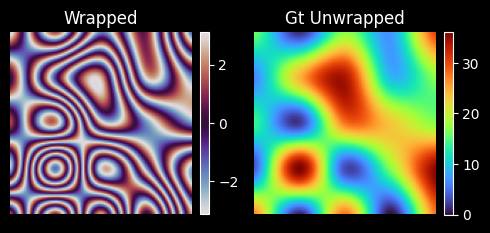

In [31]:
fig_dpi = 600
fig_size_raw = 3.5
fig_size_col = 2.5
img_path = r"res/res1/figure.pdf"
raw = 1
col = 2
fig, axes = plt.subplots(raw, col, figsize=(fig_size_col * col, fig_size_raw * raw))
axes = axes.flatten()

# raw 1, col 1
ax_0 = axes[0]
im_0 = ax_0.imshow(wrapped_mat, cmap="twilight")
ax_0.set_title("Wrapped")
ax_0.axis("off")
# ax_0.legend(frameon=False)
cbar = fig.colorbar(im_0, ax=ax_0, fraction=0.046, pad=0.04)
# cbar.locator = MultipleLocator(np.pi)
# cbar.formatter = FuncFormatter(pi_formatter)
# cbar.update_ticks()

# raw 1, col 2
ax_1 = axes[1]
im_1 = ax_1.imshow(gt_mat, cmap="turbo")
ax_1.set_title("Gt Unwrapped")
ax_1.axis("off")
# ax_1.legend(frameon=False)
cbar = fig.colorbar(im_1, ax=ax_1, fraction=0.046, pad=0.04)
# cbar.locator = MultipleLocator(np.pi)
# cbar.formatter = FuncFormatter(pi_formatter)
# cbar.update_ticks()

fig.tight_layout()
fig.savefig(img_path, dpi=fig_dpi, bbox_inches="tight")
plt.show(fig)
# plt.close(fig)

PUNet Pred

In [ ]:
import torch

In [ ]:
punet_pred_batch_path = "data/punet/pred_samples_0_1.pt"

In [ ]:
# keys: wrapped, gt_unwrapped, pred_unwrapped, diff_unwrapped
punet_pred_batch_pt = torch.load(punet_pred_batch_path)

In [ ]:
punet_pred = punet_pred_batch_pt['pred_unwrapped']

SqdLstm Pred

In [ ]:
sqd_lstm_pred_batch_path = "data/sqd_lstm/pred_samples_0_1.pt"

In [ ]:
# keys: wrapped, gt_unwrapped, pred_unwrapped, diff_unwrapped
sqd_lstm_pred_batch_pt = torch.load(punet_pred_batch_path)

In [ ]:
sqd_lstm_pred = sqd_lstm_pred_batch_pt['pred_unwrapped']

展示对比结果

In [ ]:
# tensor to numpy 2d
def _to_numpy_2d(x: torch.Tensor):
    return x.detach().cpu().squeeze().numpy()
# def _to_numpy_2d(x: torch.Tensor):
#     return x.squeeze()

In [16]:
titles = [
    "Wrapped", "GT", "PUNet",
    "SQD-LSTM"
]
imgs = [
    wrapped_mat, gt_mat, _to_numpy_2d(punet_pred), _to_numpy_2d(sqd_lstm_pred)
]
cmaps = [
    "twilight", "turbo", "turbo",
    "turbo"
]

In [ ]:
# fig_dpi = 600
# fig_size_raw = 3.5
# fig_size_col = 2.5
# img_path = r"res/res2/figure.pdf"
# raw = 1
# col = 4
# fig, axes = plt.subplots(
#     raw, col,
#     figsize=(fig_size_col * col, fig_size_raw * raw),
#     constrained_layout=True  # 启用自动布局调整
# )
# axes = axes.flatten()
# zip_list = list(zip(axes, imgs, titles, cmaps))
# # wrapped
# color_norm0 = colors.Normalize(vmin=-np.pi, vmax=np.pi)
# # 主刻度：每 π 一个
# im0 = axes[0].imshow(imgs[0], cmap=cmaps[0], norm=color_norm0)
# axes[0].set_title(titles[0])
# axes[0].axis("off")
# cbar0 = fig.colorbar(im0, ax=axes[0], orientation="horizontal", fraction=0.046, pad=0.04)
# cbar0.locator = MultipleLocator(np.pi)
# cbar0.formatter = FuncFormatter(pi_formatter)
# cbar0.update_ticks()
# cbar0.ax.tick_params(labelsize=7)
# cbar0.outline.set_visible(False)
# # cbar0.ax.set_box_aspect(0.08)
# # gt, punet, sqd-lstm
# color_norm = colors.Normalize(vmin=0)
# ims = []
# for ax, img, title, cmap in zip_list[1:]:
#     # im = ax.imshow(img, cmap=cmap)
#     im = ax.imshow(img, cmap=cmap, norm=color_norm)
#     ax.set_title(title)
#     ax.axis("off")
#     ims.append(im)
# # cax1 = fig.add_subplot(gs[1, 1:])
# cbar1 = fig.colorbar(ims[0], ax=axes[1:], orientation="horizontal", shrink=0.3)
# cbar1.locator = MultipleLocator(np.pi)
# cbar1.formatter = FuncFormatter(pi_formatter)
# cbar1.update_ticks()
# cbar1.ax.tick_params(labelsize=7)
# cbar1.outline.set_visible(False)
# # cbar1.ax.set_box_aspect(0.08)
# # fig.tight_layout()
# fig.savefig(img_path, dpi=fig_dpi, bbox_inches="tight")
# plt.show(fig)

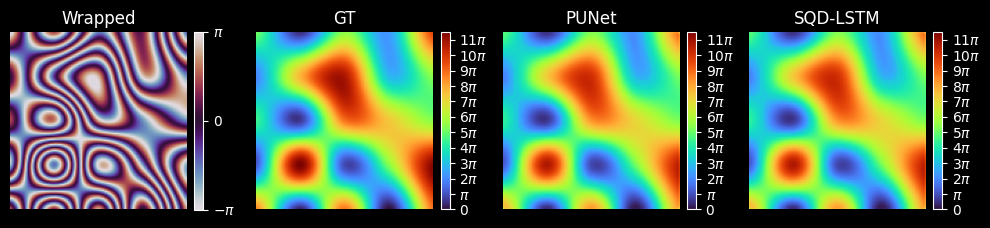

In [26]:
fig_dpi = 600
fig_size_raw = 3.5
fig_size_col = 2.5
img_path = r"res/res2/figure.pdf"
raw = 1
col = 4
fig, axes = plt.subplots(raw, col, figsize=(fig_size_col * col, fig_size_raw * raw))
# fig, axes = plt.subplots(raw, col, figsize=(fig_size_raw * col, fig_size_col * raw))
axes = axes.flatten()
zip_list = list(zip(axes, imgs, titles, cmaps))
# wrapped
color_norm = colors.Normalize(vmin=-np.pi, vmax=np.pi)
for ax, img, title, cmap in  zip_list[:1]:
    im = ax.imshow(img, cmap=cmap, norm=color_norm)
    ax.set_title(title)
    ax.axis("off")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.locator = MultipleLocator(np.pi)
    cbar.formatter = FuncFormatter(pi_formatter)
    cbar.update_ticks()
    # cbar.ax.tick_params(labelsize=7)
    # cbar.outline.set_visible(False)
# gt, punet, sqd-lstm
color_norm = colors.Normalize(vmin=0)
ims = []
for ax, img, title, cmap in zip_list[1:]:
    # im = ax.imshow(img, cmap=cmap)
    im = ax.imshow(img, cmap=cmap, norm=color_norm)
    ax.set_title(title)
    ax.axis("off")
    ims.append(im)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.locator = MultipleLocator(np.pi)
    cbar.formatter = FuncFormatter(pi_formatter)
    cbar.update_ticks()
    # cbar.ax.tick_params(labelsize=7)
    # cbar.outline.set_visible(False)
fig.tight_layout()
fig.savefig(img_path, dpi=fig_dpi, bbox_inches="tight")
plt.show(fig)